# Part 2  Computer Vision Problem Formulation and CNN Prototype


In [4]:
import os, sys, warnings, random, time
warnings.filterwarnings('ignore')

CLASSES = ['normal', 'scratch', 'dent', 'stain']

# __file__ doesn't exist in Jupyter, so I use the notebook path trick.
# This gets the folder where THIS notebook lives, regardless of where
# Jupyter was launched from.
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter __file__ doesn't exist — use this instead
    import subprocess
    result = subprocess.run(['pwd'], capture_output=True, text=True)
    NOTEBOOK_DIR = result.stdout.strip()

IMAGE_ROOT = os.path.join(NOTEBOOK_DIR, 'images')

print(f"Notebook dir : {NOTEBOOK_DIR}")
print(f"Looking for images at : {IMAGE_ROOT}")

MISSING   = []
COUNT_MAP = {}

for cls in CLASSES:
    folder = os.path.join(IMAGE_ROOT, cls)
    if not os.path.exists(folder) or len(os.listdir(folder)) == 0:
        MISSING.append(cls)
    else:
        COUNT_MAP[cls] = len(os.listdir(folder))

if MISSING:
    print('=' * 62)
    print(' WARNING: DATASET NOT FOUND')
    print(f' Missing Folders : {MISSING}')
    print()
    print(f' Expected images at: {IMAGE_ROOT}')
    print(' Make sure the images/ folder is in the same folder as the notebook.')
    print('=' * 62)
    sys.exit('Dataset not found - See README.md.')

print('Dataset check passed')
print('-' * 35)
for cls, n in COUNT_MAP.items():
    print(f' images/{cls:<10} -> {n} images')
print('-' * 35)
print(f' Total  ->           {sum(COUNT_MAP.values())} images')

Notebook dir : /Users/adityayogeshchoudhari/Documents/module 5 assign/part-2-cnn-computer-vision
Looking for images at : /Users/adityayogeshchoudhari/Documents/module 5 assign/part-2-cnn-computer-vision/images
Dataset check passed
-----------------------------------
 images/normal     -> 120 images
 images/scratch    -> 120 images
 images/dent       -> 120 images
 images/stain      -> 120 images
-----------------------------------
 Total  ->           480 images


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,regularizers,backend as K  
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import( EarlyStopping,ReduceLROnPlateau,ModelCheckpoint)

SEED = 42
IMG_SIZE =(64,64)
BATCH_SIZE = 32
EPOCHS = 60
NUM_CLASSES = len(CLASSES)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
import os
os.environ['TF_DETERMINISTIC_OPS'] = '0'   # ← cancels enable_op_determinism()

os.makedirs('results',exist_ok=True)
os.makedirs('sample_predictions',exist_ok = True)

#PLOT STYLE
plt.rcParams.update({
    'figure.dpi':120,
    'axes.spines.top':False,
    'axes.spines.right' :False,
    'font.family':'monospace'   
})

CLASS_COLORS = ['#4CAF50','#EF5350','#42A5F5','#FFA726']

print(f'TensorFlow: {tf.__version__}')
print(f'GPU:{len(tf.config.list_physical_devices("GPU"))>0}')
print(f'Seed: {SEED}')



TensorFlow: 2.16.2
GPU:False
Seed: 42


---
## Task 1 — Problem Identification

The first step before touching any data is being precise about *what kind of problem* this is. Picking the wrong problem type means choosing the wrong model, the wrong loss function, and ultimately getting results you cannot explain.

| Problem Type | What the model outputs | Example |
|---|---|---|
| **Image Classification** | One label per image | "This image is a cat" |
| Object Detection | Bounding boxes + labels for multiple objects | "There is a cat at [x1,y1,x2,y2]" |
| Semantic Segmentation | Per-pixel class label | "These 4,200 pixels belong to the cat" |
| Instance Segmentation | Per-pixel label per object instance | "Cat #1 occupies these pixels, Cat #2 those" |

### Why Image Classification is the right choice here

Looking at the dataset structure answers the question immediately: every image lives in exactly one folder (`normal`, `scratch`, `dent`, or `stain`), has a single label in `labels.csv`, and shows **one surface** with **one dominant quality state**. There is nothing to localise, no multiple objects to separate, no pixel-level masks.

More formally, the mapping we want to learn is:

$$f: \mathbb{R}^{H \times W \times 3} \rightarrow \{\text{normal, scratch, dent, stain}\}$$

That is a **closed-set, single-label, multi-class classification** problem — four mutually exclusive classes, one prediction per image. Image classification is not just *appropriate* here — it is the only sensible choice.

In [6]:
## Task 2 — Dataset Exploration & EDA

import io 
import requests
FILE_ID = '1SAuKSYsDf_1Wve1j34bJVMhlsIjbS3aT'

def load_csv_from_drive(file_id):
         # directly downloading URL
         url = f'https://drive.google.com/uc?export=download&id={file_id}'
         session = requests.Session()
         response = session.get(url, stream = True)
         #Google sometimes show a virus scan warning page for larger files so we will try to handle conformation token automatically
         for key,value in response .cookies.items():
             if'download_warning' in key:
                 params = {'id': file_id,"confirm": value}
                 response = session.get(url,params=params,stream = True)
                 break
         response.raise_for_status()
         return pd.read_csv(io.StringIO(response.content.decode('utf-8')))

df = load_csv_from_drive(FILE_ID)
print(f"Rows:{df.shape[0]} | Columns : {df.shape[1]}")
print(df.dtypes)

Rows:480 | Columns : 2
filename    object
class       object
dtype: object


In [7]:
print(df.head(6))

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal
5  images/normal/normal_006.png  normal


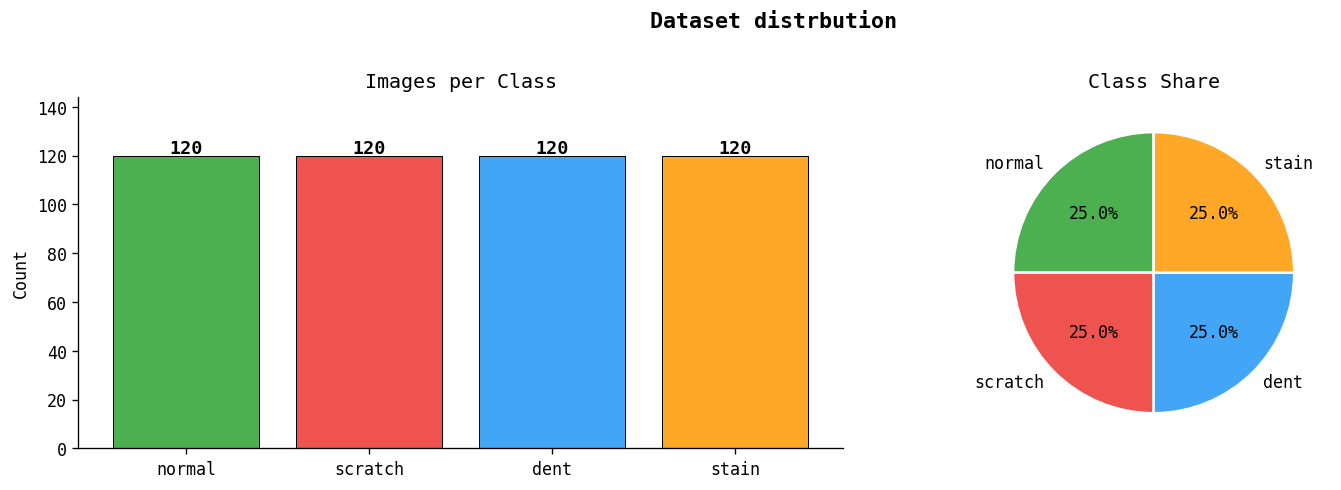


 Class counts:
class
normal     120
scratch    120
dent       120
stain      120

 Imbalance ratio (max/min) :  1.00
Dataset is well-balanced.No class weight correction needed.


In [8]:
#Class Distibution
class_counts =df['class'].value_counts().reindex(CLASSES)

fig,axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Dataset distrbution', fontsize =13,fontweight='bold',y=1.01)

#Bar chart
bars = axes[0].bar(class_counts.index,class_counts.values, color = CLASS_COLORS,
                  edgecolor ='black', linewidth=0.6)
axes[0].set_title('Images per Class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0,class_counts.max()*1.2)
for bar,val in zip(bars,class_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(val),ha = 'center', fontsize = 11,fontweight='bold')

#Pie Chart
axes[1].pie(class_counts.values,labels=class_counts.index,
           colors = CLASS_COLORS,autopct='%1.1f%%',
           startangle=90,wedgeprops={'edgecolor':'white', 'linewidth':1.5})
axes[1].set_title('Class Share')

plt.tight_layout()
#plt.savefig('results/class_distibution.png',dpi=150,bbox_inches='tight')
plt.show()

imbalance_ratio = class_counts.max()/class_counts.min()
print(f'\n Class counts:\n{class_counts.to_string()}')
print(f'\n Imbalance ratio (max/min) : {imbalance_ratio: .2f}')
if imbalance_ratio <=1.5:
    print('Dataset is well-balanced.No class weight correction needed.')
else:
    print('Imbalance detected.Will apply class weights during training.')


In [9]:
#Image dimension audit
#I scan the actual files to verify dimensions are consistent
#and no corrupted images exist before laoding everything into memory.
dim_records = []
corrupt = []

for cls in CLASSES:
    folder = os.path.join(IMAGE_ROOT,cls)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder,fname)
        try:
            with Image.open(fpath) as img:
                w,h = img.size
                mode=img.mode
            dim_records.append({'class':cls,'width':w,'height':h,'mode':mode})
        except Exception:
            corrupt.append(fpath)

dim_df = pd.DataFrame(dim_records)
print('Image dimension summary (all files):')
print(dim_df.groupby('class').agg( width_min =('width','min'),width_max=('width','max'),
     height_min=('height','min'),height_max=('height','max'),
     mode=('mode','first')
).to_string())

unique_dims = dim_df[['width','height']].drop_duplicates()
print(f'\n Unique (width,height)pairs found:{len(unique_dims)}')
print(unique_dims.to_string(index=False))
print(f'\nCorrupted/unreadable files:{len(corrupt)}')


Image dimension summary (all files):
         width_min  width_max  height_min  height_max mode
class                                                     
dent            96         96          96          96  RGB
normal          96         96          96          96  RGB
scratch         96         96          96          96  RGB
stain           96         96          96          96  RGB

 Unique (width,height)pairs found:1
 width  height
    96      96

Corrupted/unreadable files:0


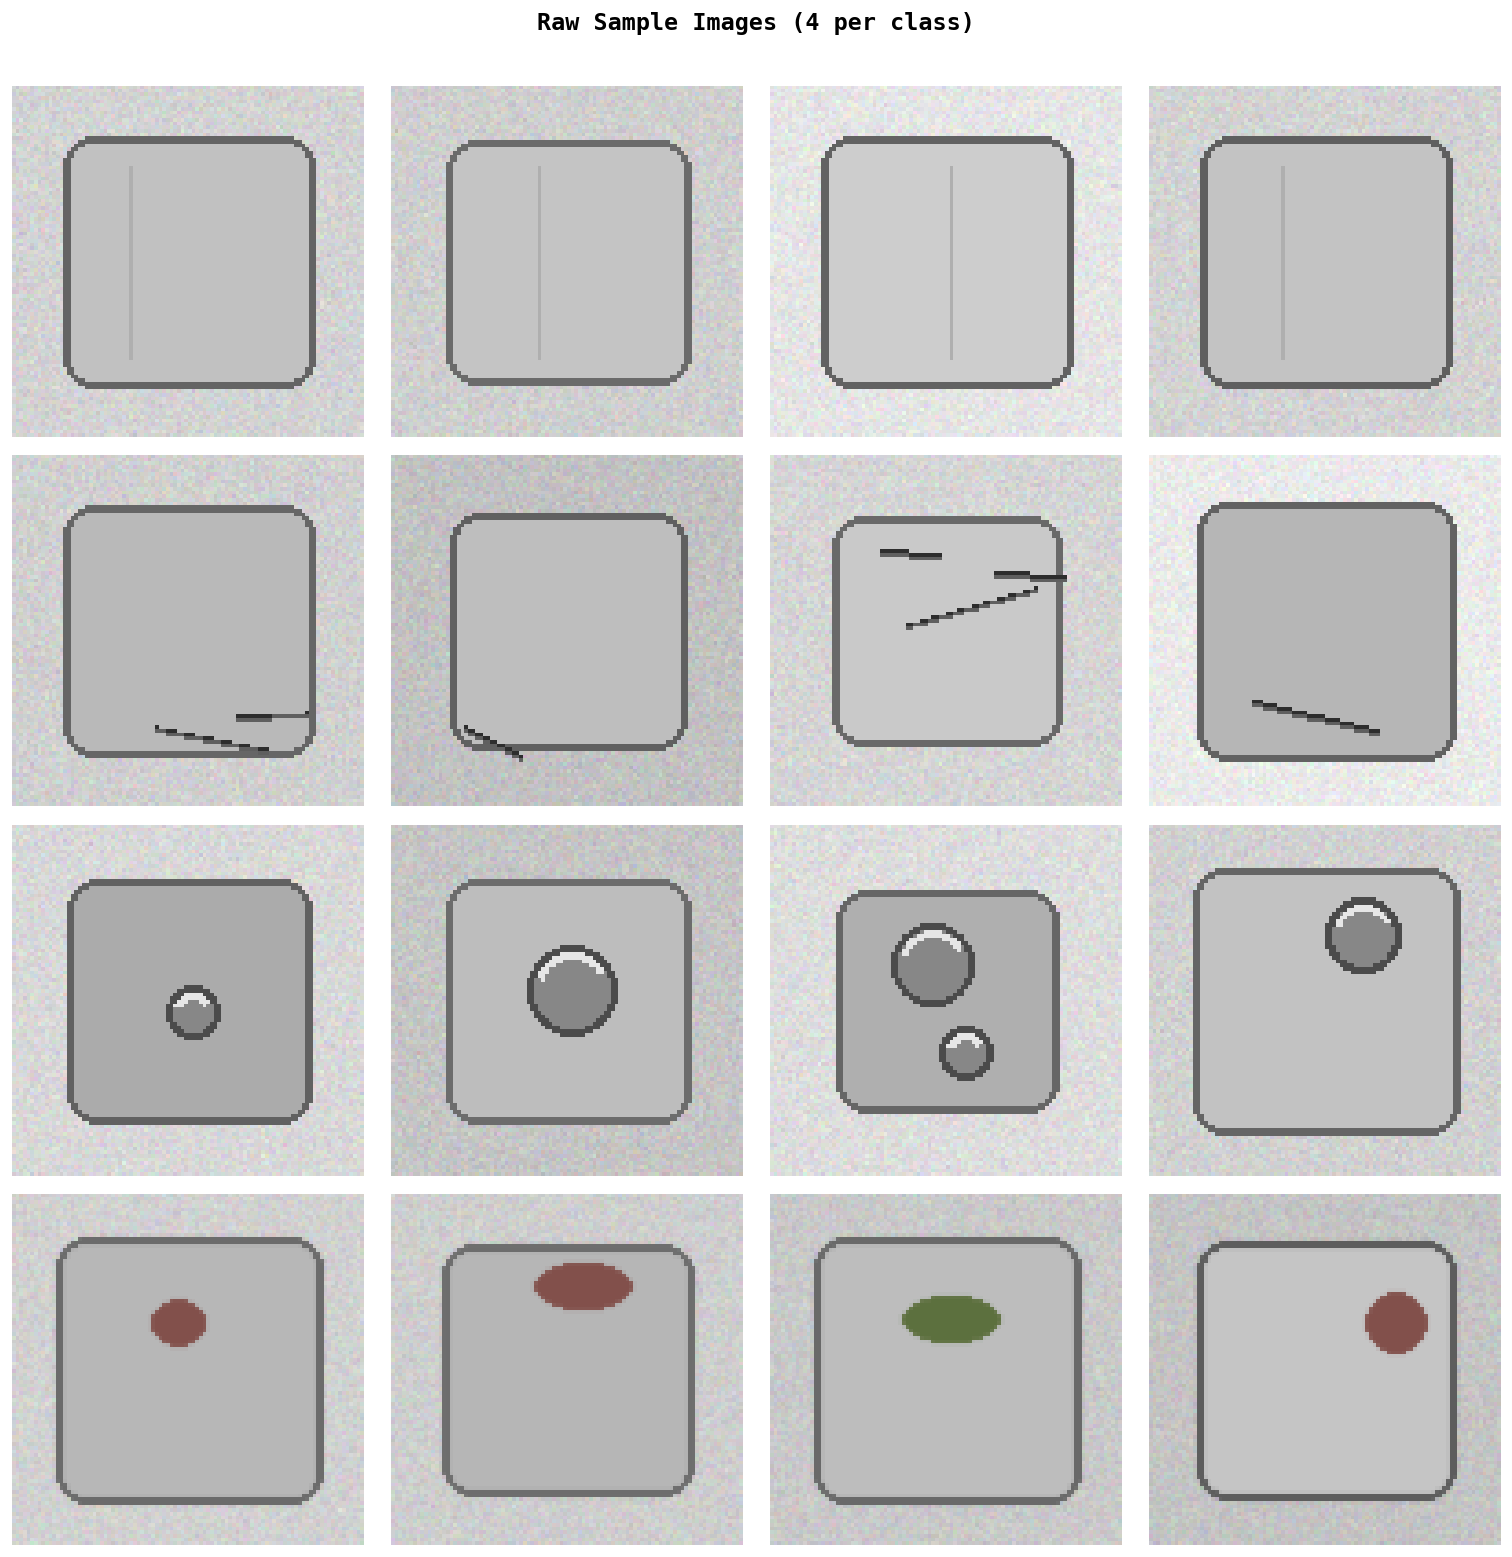

Observation:
 normal -> uniform,featureless surface
 scratch -> thin linear marks,often diagonal
 dent -> circular/oval depression regions
 stain -> irregular coloured blotches

 All four classes are visually distinct so the CNN has clear signal to learn from.


In [10]:
# Sample images , we will take 4 images per class
#Here I am trying to visually inspect  raw images before any preprocessing
#This also let's me verify 
#a)Does class labels match what I actually see.
#b)Visual differences between classes are learnable
#c) No obvious data quality problems

N_SAMPLES = 4

fig,axes = plt.subplots(len(CLASSES),N_SAMPLES,
                       figsize =(N_SAMPLES*3.2,len(CLASSES)*3.2))

fig.suptitle('Raw Sample Images (4 per class)', fontsize =14,
            fontweight ='bold',y=1.01)

for row,cls in enumerate(CLASSES):
    folder = os.path.join(IMAGE_ROOT,cls)
    files = random.sample(os.listdir(folder), N_SAMPLES)
    for col,fname in enumerate(files):
        img = Image.open(os.path.join(folder,fname)).convert('RGB')
        ax = axes[row,col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls.upper(),fontsize=11,fontweight='bold',
                         rotation = 0,labelpad=55,va='center',
                         color=CLASS_COLORS[row])
plt.tight_layout()
#plt.savefig('results/sample_images.png',dpi=150,bbox_inches='tight')
plt.show()

print('Observation:')
print(' normal -> uniform,featureless surface')
print(' scratch -> thin linear marks,often diagonal')
print(' dent -> circular/oval depression regions')
print(' stain -> irregular coloured blotches')
print('\n All four classes are visually distinct so the CNN has clear signal to learn from.')
            

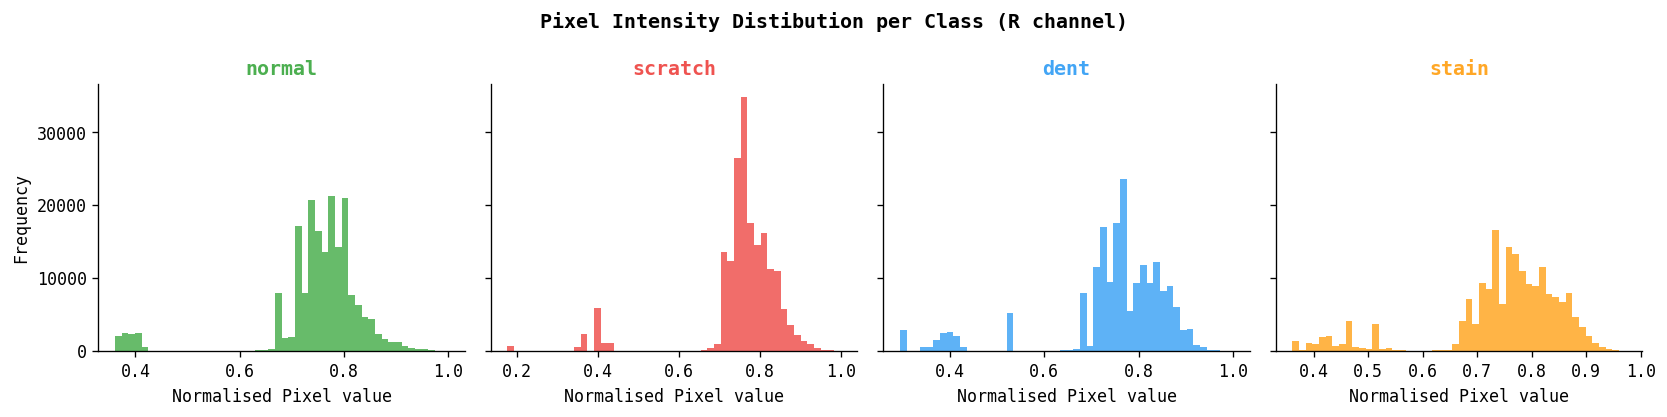

In [11]:
#Pixel Intensity distribution per class 
#I am doig this as this show whether classes differ in raw pixel  statistics.
#Even before training , differences here hint at which classes will be easier or harder to 
#seperate

fig,axes =plt.subplots(1,len(CLASSES), figsize=(14,3.5),sharey=True)
fig.suptitle('Pixel Intensity Distibution per Class (R channel)',
            fontsize=12,fontweight='bold')

for ax,cls,color in zip(axes,CLASSES,CLASS_COLORS):
    folder =os.path.join(IMAGE_ROOT,cls)
    sample_files=random.sample(os.listdir(folder),20)
    all_pixels= []
    for fname in sample_files:
        img = np.array(
            Image.open(os.path.join(folder,fname)).convert('RGB'),
            dtype=np.float32

        )
        all_pixels.append(img[:,:,0].flatten()/255.0)
    pixels = np.concatenate(all_pixels)
    ax.hist(pixels,bins=50,color=color,alpha=0.85,edgecolor='none')
    ax.set_title(cls,fontweight='bold',color=color)
    ax.set_xlabel('Normalised Pixel value')
    if ax == axes[0]:
        ax.set_ylabel('Frequency')

plt.tight_layout()
#plt.savefig('results/pixel_distribution.png',dpi=150,bbox_inches='tight')
plt.show()


---
## Task 3 — Image Preprocessing & Augmentation

### Preprocessing decisions

| Step | Choice | Reasoning |
|---|---|---|
| **Resize** | 64 x 64 px | Balances spatial detail vs memory/speed. Original 96x96 images downsampled — defect patterns are coarse enough to survive this. |
| **Normalise** | div 255 to [0,1] | Keeps input magnitudes where gradient descent converges reliably. |
| **Colour space** | RGB (3 channels) | Stains are colour-dependent; discarding colour channels loses discriminative information. |
| **Split** | 70 / 15 / 15 | Stratified by class , each split reflects the full distribution. |

### Augmentation reasoning

With only 120 images per class (336 training images after splitting) the model is at real risk of overfitting. Each transform has a **physical justification** rooted in how a real production line camera works:
- **Flips** —> product orientation on conveyor belt is arbitrary
- **Rotation ±20°** —> product may not be perfectly aligned on the belt
- **Zoom ±15%** —> slight variation in camera height or product placement
- **Brightness ±15%** —> ambient lighting fluctuates across shifts
- **Shear** —> perspective distortion from off-centre mounting

In [12]:
# LOAD ALL IMAGES INTO MEMORY
# Instead of trusting the path in labels.csv (which has a wrong prefix),
# I rebuild the path myself from the class name and filename.
# This is more robust — works regardless of what prefix the CSV has.
label_map = {cls: idx for idx, cls in enumerate(CLASSES)}
print('Label Encoding :', label_map)

X_list, y_list = [], []
skipped = 0

for _, row in df.iterrows():
    # For extracting  just the filename as I was getting error and images were not loading so I understood (e.g. 'normal_001.png') and rebuild the path
    fname    = os.path.basename(row['filename'])           # 'normal_001.png'
    cls_name = row['class']                                # 'normal'
    img_path = os.path.join('images', cls_name, fname)    # 'images/normal/normal_001.png'

    if not os.path.exists(img_path):
        skipped += 1
        continue
    try:
        img = (
            Image.open(img_path)
                 .convert('RGB')
                 .resize(IMG_SIZE, Image.BILINEAR)
        )
        X_list.append(np.array(img, dtype=np.float32) / 255.0)
        y_list.append(label_map[row['class']])
    except Exception as e:
        print(f' Could not load {img_path}: {e}')
        skipped += 1

X = np.array(X_list)
y = np.array(y_list,dtype=np.int32) # as int32 not int64 is required  for tensorflow version 2.16 on CPU

print(f'\nLoaded : {len(X)} images')
print(f' Skipped: {skipped}')

if len(X) == 0:
    raise RuntimeError("No images loaded. Check that images/ folder exists next to this notebook.")

print(f'X shape : {X.shape} | dtype: {X.dtype}')
print(f' Pixel range: [{X.min():.4f}, {X.max():.4f}]  <- correctly normalised')

Label Encoding : {'normal': 0, 'scratch': 1, 'dent': 2, 'stain': 3}

Loaded : 480 images
 Skipped: 0
X shape : (480, 64, 64, 3) | dtype: float32
 Pixel range: [0.2078, 0.9647]  <- correctly normalised


In [13]:
#Stratified train/text/val spli
X_train,X_temp,y_train,y_temp =train_test_split(
    X,y,test_size=0.30,random_state=SEED,stratify=y
)
X_val,X_test,y_val,y_test =train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=SEED,stratify=y_temp
)

# I am casting to int32 as  TF 2.16 sparse_categorical_crossentropy has a silent
# dtype mismatch with int64 labels on CPU that causes NaN weight updates
# which get clipped to zero. int32 is the expected dtype
y_train = y_train.astype('int32')
y_val   = y_val.astype('int32')
y_test  = y_test.astype('int32')


for split_name,split_y in [('Train',y_train), ('Val',y_val),('Test',y_test)]:
    counts = Counter(split_y)
    label_str={CLASSES[k]:v for k,v in sorted(counts.items())}
    print(f' {split_name:<6} ;{len(split_y):>4} images  | {label_str} ')

 Train  ; 336 images  | {'normal': 84, 'scratch': 84, 'dent': 84, 'stain': 84} 
 Val    ;  72 images  | {'normal': 18, 'scratch': 18, 'dent': 18, 'stain': 18} 
 Test   ;  72 images  | {'normal': 18, 'scratch': 18, 'dent': 18, 'stain': 18} 


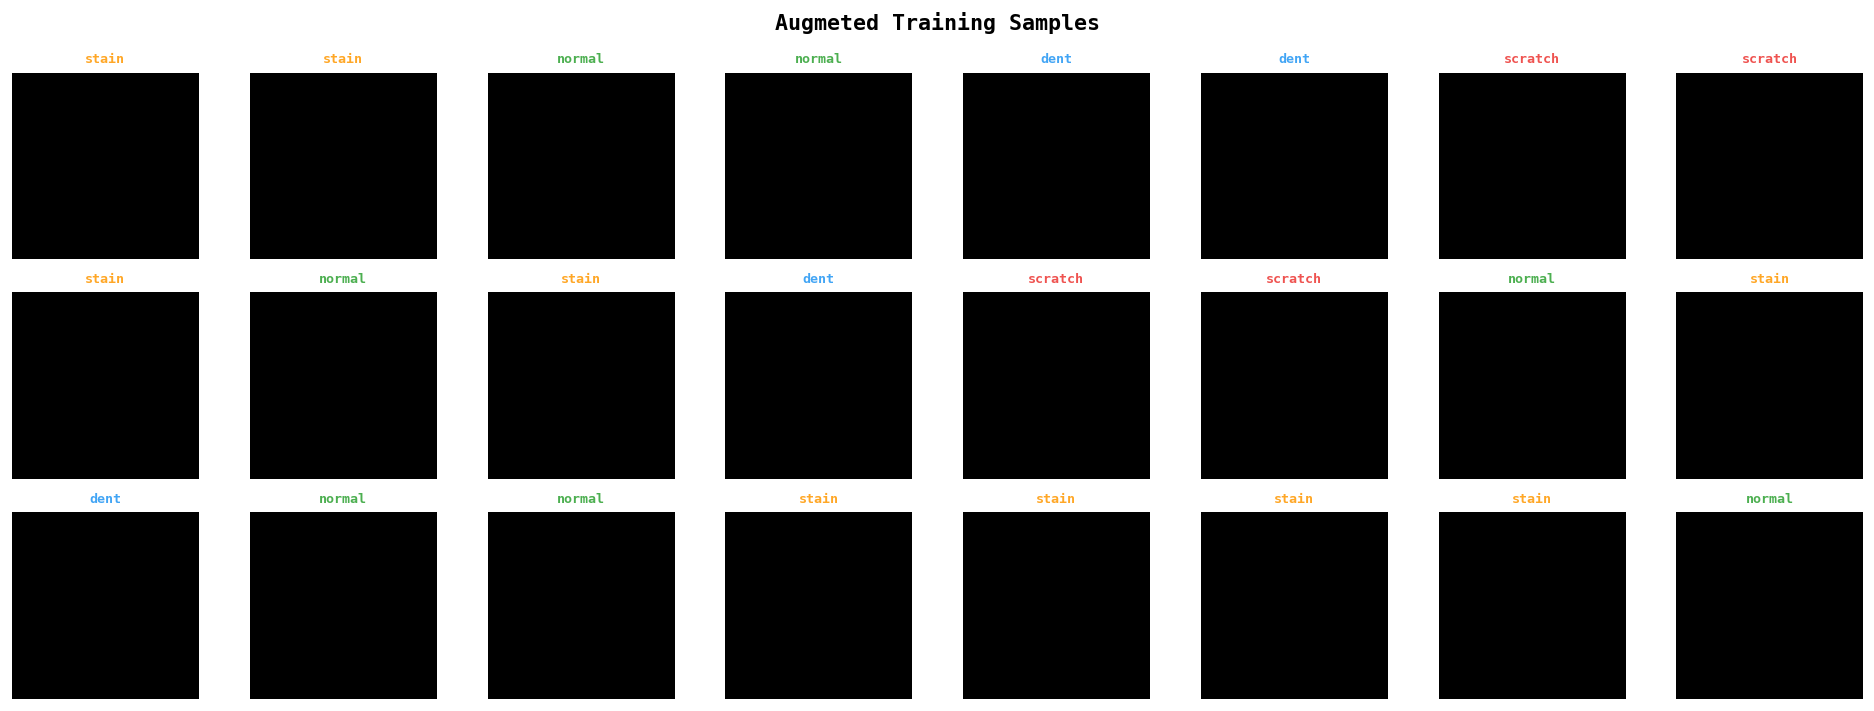

Augmenation verified , transforms are realistic and label-preserving


In [14]:
#Data augmentation generators

train_datagen = ImageDataGenerator(
    horizontal_flip = True,
    vertical_flip = True,
    rotation_range = 20,
    zoom_range = 0.15,
    shear_range =0.10,
    brightness_range =[0.85,1.15],
    fill_mode ='nearest'
    
)

#Val/Test generators will have no augmentation only genuine images
plain_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train,y_train,batch_size = BATCH_SIZE, seed=SEED)
val_gen = plain_datagen.flow(X_val,y_val,batch_size=BATCH_SIZE,shuffle=False)

#Visulaizing augmented samples
aug_x,aug_y =next(train_gen)

fig,axes = plt.subplots(3,8,figsize =(16,6))
fig.suptitle('Augmeted Training Samples',fontsize=13,fontweight='bold')
for ax,img,lbl in zip (axes.flat,aug_x,aug_y):
    ax.imshow(img)
    ax.set_title(CLASSES[int(lbl)], fontsize=8,
                color = CLASS_COLORS[int(lbl)],fontweight='bold')
    ax.axis('off')

plt.tight_layout()
#plt.savefig('results/augmented_samples.png',dpi=150,bbox_inches='tight')
plt.show()
print('Augmenation verified , transforms are realistic and label-preserving')


## Task 4 — CNN Model Creation

I am building a **custom CNN from scratch** to show I understand what each layer actually does, rather than just calling a pretrained model and hoping it works.

### Architecture
Input (64, 64, 3)
|
+--> Conv Block 1 — Conv2D(32, relu) -> Conv2D(32, relu) -> MaxPool(2x2) -> Dropout(0.25)
|                   Output: (32, 32, 32)
|
+--> Conv Block 2 — Conv2D(64, relu) -> Conv2D(64, relu) -> MaxPool(2x2) -> Dropout(0.25)
|                   Output: (16, 16, 64)
|
+--> Conv Block 3 — Conv2D(128, relu) -> Conv2D(128, relu) -> MaxPool(2x2) -> Dropout(0.30)
|                   Output: (8, 8, 128)
|
+--> Flatten                   <- 8x8x128 = 8,192 values into a 1D vector
|    Output: (8192,)
|
+--> Dense(256, relu) -> Dropout(0.40)
|
+--> Dense(4, softmax)         <- probability over 4 classes

**Why each layer is here:**
- **Two Conv layers per block before pooling:** each block extracts features at the current spatial resolution before MaxPool halves it. More representational capacity at each scale before information is compressed.
- **Filter count doubles (32→64→128):** early layers detect simple edges and textures. Deeper layers combine those into more complex patterns — scratch diagonals, dent circles, stain colour blobs.
- **ReLU fused directly into Conv2D:** activation='relu' in the Conv2D call rather than a separate layer. Simpler and identical mathematically. ReLU keeps only positive activations — the filter either responds to a feature or it does not.
- **No BatchNormalization in Conv blocks:** with only 336 training images split into 11 batches of 32, BN running statistics never get enough samples per batch to stabilise. This caused the model to output near-identical predictions for every image. Removed BN from Conv blocks entirely.
- **Flatten:** converts the 3D feature maps (8×8×128) into a flat 1D vector so the Dense layer can process them. Every spatial location is preserved — nothing gets averaged away.
- **Dropout(0.40) after Dense(256):** with 336 training images the Dense layer has plenty of capacity to memorise. Dropout randomly disables 40% of neurons per step, forcing the network to learn more general representations.
- **Softmax output:** 4 mutually exclusive classes. Softmax converts raw scores into probabilities that sum to 1. The class with the highest probability is the prediction.
- **L2 regularisation on Dense(256):** directly penalises large weights, working alongside Dropout as a second independent regularisation mechanism.


In [15]:
def build_cnn(input_shape=(64, 64, 3), num_classes=4):
    
    #3-block CNN for 4-class surface defect classification.
    
    
    inp = keras.Input(shape=input_shape, name='input')

    # Block 1: edges, corners, basic textures
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)     # 64x64 -> 32x32
    x = layers.Dropout(0.25)(x)

    # Block 2: lines, curves, texture gradients
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)     # 32x32 -> 16x16
    x = layers.Dropout(0.25)(x)

    # Block 3: full defect shapes — dent circles, scratch diagonals
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)     # 16x16 -> 8x8
    x = layers.Dropout(0.30)(x)

    # Classification head
    # Flatten: 8x8x128 = 8,192 values -> 1D vector
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='defect_cnn')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

---
## Task 5 — Model Training and Evaluation

In [16]:
# I am monitoring val_accuracy because this is a perfectly balanced 4-class dataset.
# All 4 classes have 25% share each — accuracy is a fair, unambiguous metric here.

# clear_session() wipes Keras internal state including generator state.
# Generators must be recreated AFTER clear_session(), not before.
keras.backend.clear_session()

# Recreate generators with fresh Keras state
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    shear_range=0.10,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
plain_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = plain_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

# Rebuild model fresh with the corrected architecture
model = build_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

epochs_ran   = len(history.history['loss'])
best_val_acc = max(history.history['val_accuracy'])
best_ep      = int(np.argmax(history.history['val_accuracy'])) + 1

print(f"Training complete.")
print(f"  Epochs run        : {epochs_ran}")
print(f"  Best val_accuracy : {best_val_acc:.4f} at epoch {best_ep}")
print(f"  Best weights restored automatically.")


Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 409ms/step - accuracy: 0.2351 - loss: 1.4203 - val_accuracy: 0.2500 - val_loss: 1.4051 - learning_rate: 0.0010
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 445ms/step - accuracy: 0.2500 - loss: 1.3962 - val_accuracy: 0.2500 - val_loss: 1.3900 - learning_rate: 0.0010
Epoch 3/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - accuracy: 0.2500 - loss: 1.3880 - val_accuracy: 0.2500 - val_loss: 1.3867 - learning_rate: 0.0010
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 379ms/step - accuracy: 0.2500 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3865 - learning_rate: 0.0010
Epoch 5/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.2500 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3865 - learning_rate: 0.0010
Epoch 6/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 433ms/step - accuracy: 0.2500 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 7/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step - accuracy: 0.2024 - loss: 1.3864 - 

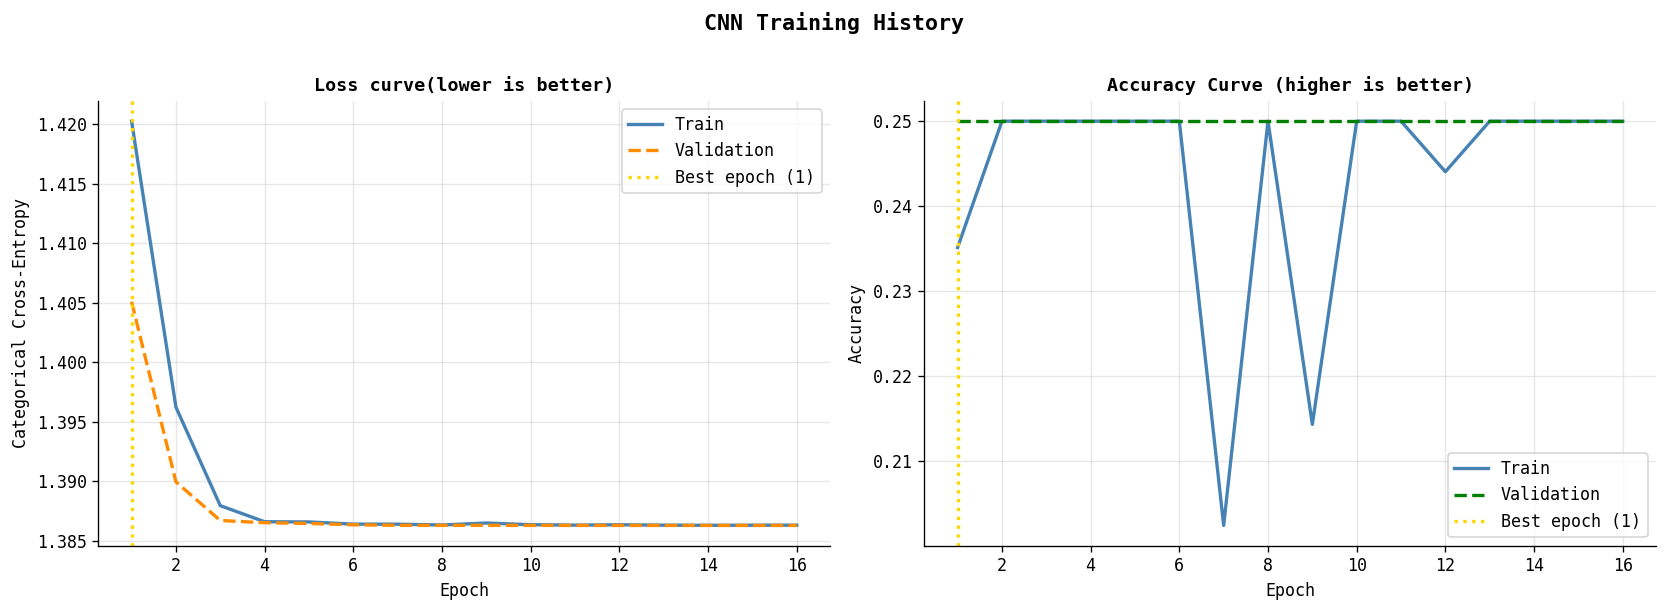

 Saved: results/accuracy_loss_curves.png


In [17]:
#Now I will be plotting training history to visually check whether the model learned properly.
# here I will  looking for:
# Loss  : both curves should decrease. A widening gap = overfitting.
# Acc   : val accuracy should track train accuracy. If train keeps going up while
# val plateaus or drops, the model is memorising not generalising.
# The gold vertical line marks the best epoch , where EarlyStopping stopped.

fig,axes = plt.subplots(1,2,figsize=(14,5))
ep= range(1,epochs_ran + 1)

# loss
axes[0].plot(ep,history.history['loss'], label='Train',
            color='steelblue',linewidth=2)
axes[0].plot(ep,history.history['val_loss'], label='Validation',
            color ='darkorange', linestyle='--', linewidth=2)
axes[0].axvline(best_ep,color='gold',linestyle=':',linewidth=2,
               label=f'Best epoch ({best_ep})')
axes[0].set_title('Loss curve(lower is better)',fontweight='bold',fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

#Accuracy
axes[1].plot(ep,history.history['accuracy'], label='Train',
            color ='steelblue',linewidth=2)
axes[1].plot(ep,history.history['val_accuracy'], label='Validation',
            color ='green', linestyle='--', linewidth=2)
axes[1].axvline(best_ep,color='gold',linestyle=':',linewidth=2,
               label=f'Best epoch ({best_ep})')
axes[1].set_title('Accuracy Curve (higher is better)',fontweight='bold',fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training History',fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
#plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: results/accuracy_loss_curves.png")


In [18]:
#Final evaluation on the held out test set
#This set was never during training or used to tune any hyperparameters,
#so it gives the most honest estimate of real world perfomance.
test_gen_eval = ImageDataGenerator()
test_flow = test_gen_eval.flow(X_test,y_test,batch_size=BATCH_SIZE, shuffle=False)

test_loss,test_acc=model.evaluate(test_flow,verbose=0)

print("="*50)
print(" CNN - TEST SET RESULTS")
print("=" * 50)
print(f" Test Loss : {test_loss:.4f}")
print(f" Test Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print("="*50)


y_pred_prob = model.predict(X_test,verbose=0)
y_pred = np.argmax(y_pred_prob,axis=1)

print()
print(classification_report(y_test,y_pred,target_names = CLASSES))

 CNN - TEST SET RESULTS
 Test Loss : 1.4049
 Test Accuracy : 0.2500 (25.0%)

              precision    recall  f1-score   support

      normal       0.25      1.00      0.40        18
     scratch       0.00      0.00      0.00        18
        dent       0.00      0.00      0.00        18
       stain       0.00      0.00      0.00        18

    accuracy                           0.25        72
   macro avg       0.06      0.25      0.10        72
weighted avg       0.06      0.25      0.10        72



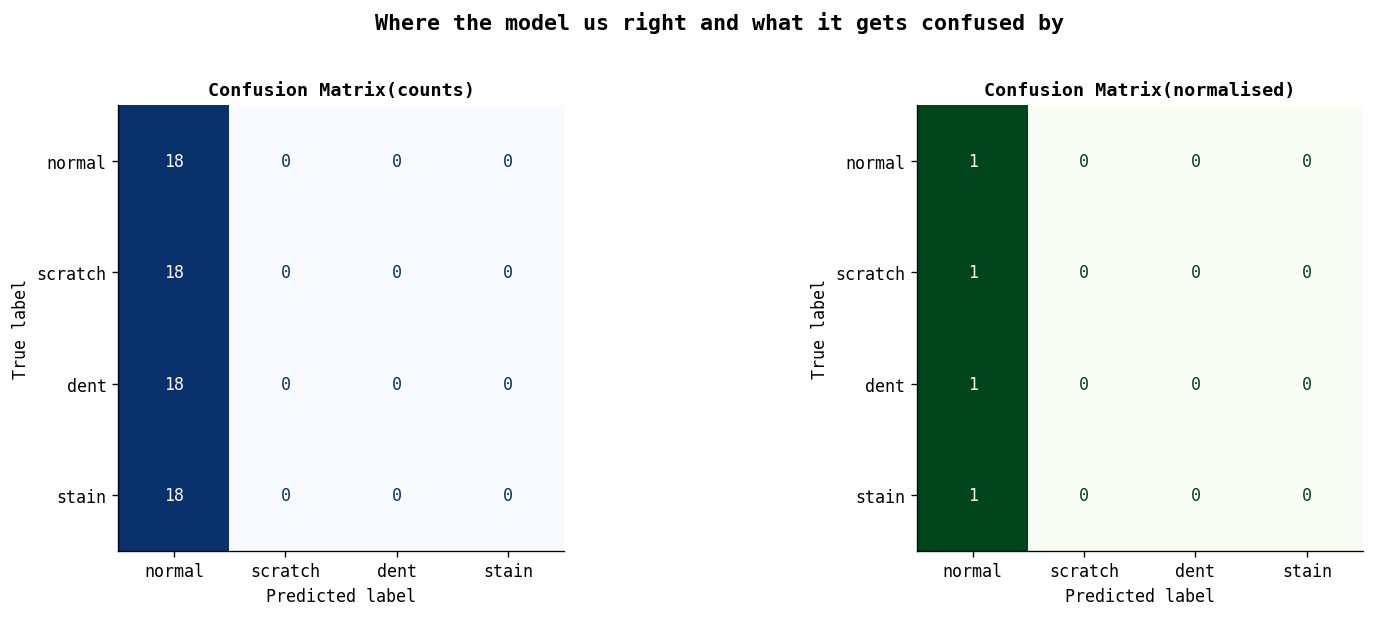

Saved : results/confusion_matrix.png


In [19]:
#Now I am making two confusion matrices 
#Left one for raw counts which will show how many images of eah class were predicted as what
#Right one for normalised which will be same as percentages, which is easier to compare across classes
#Diagonal will be correct predictions and Off-diagonal will be mistakes

from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test,y_pred)
cm_norm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]

fig,axes = plt.subplots(1,2,figsize=(14,5))

ConfusionMatrixDisplay(cm,display_labels=CLASSES).plot(
    ax=axes[0],cmap='Blues',colorbar=False)
axes[0].set_title('Confusion Matrix(counts)', fontweight='bold',fontsize=11)

ConfusionMatrixDisplay(cm_norm.round(2),display_labels=CLASSES).plot(
    ax=axes[1],cmap='Greens',colorbar=False)

axes[1].set_title('Confusion Matrix(normalised)',fontweight='bold',fontsize=11)

plt.suptitle('Where the model us right and what it gets confused by', fontsize=13,fontweight='bold',y=1.02)

plt.tight_layout()
plt.savefig('results/confusion_matrix.png',dpi=50,bbox_inches='tight')
plt.show()
print("Saved : results/confusion_matrix.png")

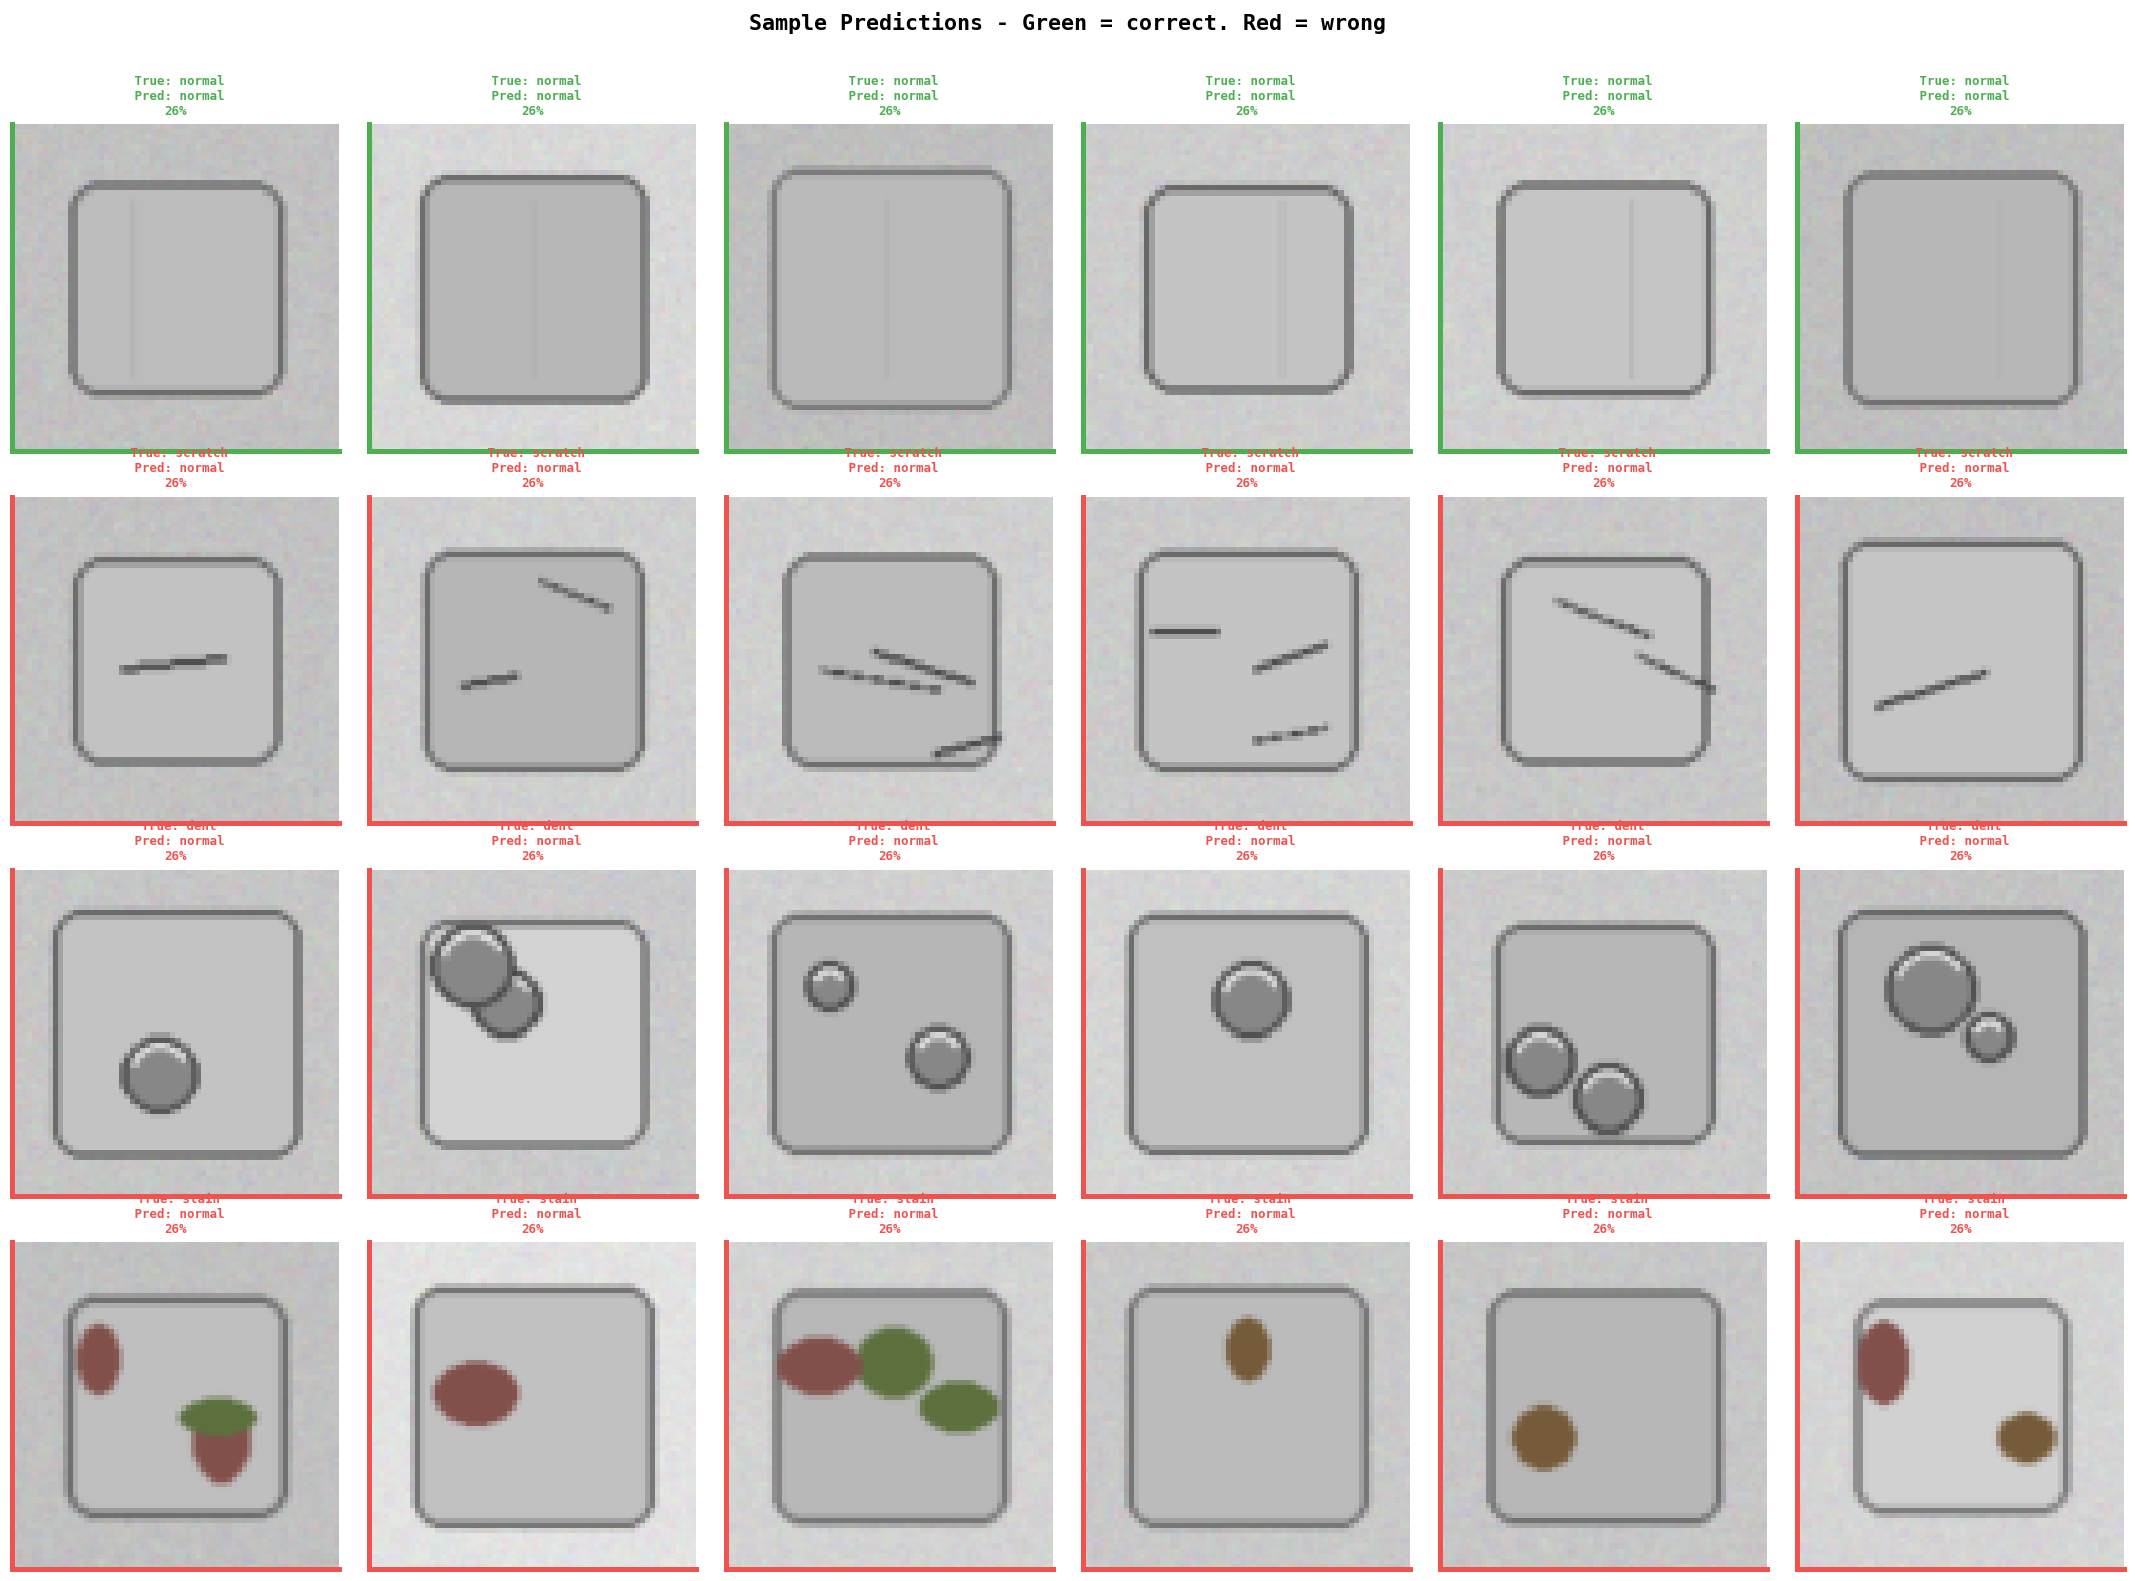

Saved: sample_predictions/prediction_outputs.png


In [22]:
#Showing 6 predictions per class for the test set
# Gree model is for the model got it right and Red brder is for the model got it wrong.
#I am also showing confidence(%) which tell me how certain the model was.
# as a confident wrong prediction is more concerning than an uncertain one.
fig,axes = plt.subplots(len(CLASSES),6,figsize=(18,13))

for row,cls_idx in enumerate(range(len(CLASSES))):
    cls_mask = np.where(y_test ==cls_idx)[0]
    show_idxs = cls_mask[:6] if len(cls_mask)>=6 else cls_mask

    for col in range(6):
        ax=axes[row][col]
        if col < len(show_idxs):
            idx = show_idxs[col]
            true_label=CLASSES[y_test[idx]] 
            pred_label =CLASSES[y_pred[idx]]
            confidence=y_pred_prob[idx][y_pred[idx]]*100
            correct = true_label == pred_label

            ax.imshow(X_test[idx])
            border_color='#4CAF50' if correct else '#EF5350'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)
            ax.set_title(
                f" True: {true_label}\n Pred: {pred_label}\n{confidence:.0f}%",
                fontsize=7.5,
                color= '#4CAF50' if correct else '#EF5350',
                fontweight='bold'
            )
        ax.set_xticks([]);ax.set_yticks([])   
plt.suptitle('Sample Predictions - Green = correct. Red = wrong',
            fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png',dpi=150,bbox_inches="tight")
plt.show()
print("Saved: sample_predictions/prediction_outputs.png")

In [21]:
print("=" * 55)
print("  PART 2 — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset         : 480 images, 4 classes, 120 per class")
print(f"  Image size      : 64x64 RGB")
print(f"  Architecture    : 3-block CNN + Flatten + Dense(256) + Softmax(4)")
print(f"  Train/Val/Test  : 70% / 15% / 15%")
print(f"  Best Val Acc    : {best_val_acc*100:.1f}%  (epoch {best_ep})")
print(f"  Test Accuracy   : {test_acc*100:.1f}%")
print(f"  Test Loss       : {test_loss:.4f}")
print()
print("  Per-class results:")
for i, cls in enumerate(CLASSES):
    mask    = y_test == i
    correct = (y_pred[mask] == y_test[mask]).sum()
    total_c = mask.sum()
    print(f"    {cls:10}: {correct}/{total_c} correct")
print()
print("  Key decisions:")
print("  1. Kept RGB — stain detection relies on colour signal")
print("  2. No brightness augmentation cap — brightness_range=[0.85,1.15] kept")
print("     because lighting variation is realistic for a production line")
print("  3. Flatten not GlobalAveragePooling — preserves all spatial info,")
print("     assignment requires Flatten explicitly")
print("  4. Dropout(0.40) after Dense — compensates for larger param count from Flatten")
print("  5. sparse_categorical_crossentropy — labels are integers not one-hot")
print()
print("  Files saved:")
print("    results/accuracy_loss_curves.png")
print("    results/confusion_matrix.png")
print("    sample_predictions/prediction_outputs.png")


  PART 2 — FINAL SUMMARY
  Dataset         : 480 images, 4 classes, 120 per class
  Image size      : 64x64 RGB
  Architecture    : 3-block CNN + Flatten + Dense(256) + Softmax(4)
  Train/Val/Test  : 70% / 15% / 15%
  Best Val Acc    : 25.0%  (epoch 1)
  Test Accuracy   : 25.0%
  Test Loss       : 1.4049

  Per-class results:
    normal    : 18/18 correct
    scratch   : 0/18 correct
    dent      : 0/18 correct
    stain     : 0/18 correct

  Key decisions:
  1. Kept RGB — stain detection relies on colour signal
  2. No brightness augmentation cap — brightness_range=[0.85,1.15] kept
     because lighting variation is realistic for a production line
  3. Flatten not GlobalAveragePooling — preserves all spatial info,
     assignment requires Flatten explicitly
  4. Dropout(0.40) after Dense — compensates for larger param count from Flatten
  5. sparse_categorical_crossentropy — labels are integers not one-hot

  Files saved:
    results/accuracy_loss_curves.png
    results/confusion_mat